# Merged APPA-EEA Dataset Exploration
This notebook explores the structure, statistics, and characteristics of the merged dataset combining APPA station data with EEA regional measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the merged dataset
merged_df = pd.read_csv('./output/merged_appa_eea.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {merged_df.shape}")

Dataset loaded successfully!
Shape: (34302, 152)


/tmp/ipykernel_682786/1749933032.py:11: DtypeWarning: Columns (151) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv('./output/merged_appa_eea.csv')


## 1. Dataset Overview

In [2]:
# Display basic information
print("=== DATASET INFORMATION ===")
print(f"Total Rows: {merged_df.shape[0]:,}")
print(f"Total Columns: {merged_df.shape[1]:,}")
print(f"Memory Usage: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDate Range: {merged_df['Data'].min()} to {merged_df['Data'].max()}")
print(f"\nUnique Stations: {merged_df['Stazione'].nunique()}")
print(f"Unique Weather Stations: {merged_df['StazioneMeteo'].nunique()}")

=== DATASET INFORMATION ===
Total Rows: 34,302
Total Columns: 152
Memory Usage: 99.27 MB

Date Range: 2013-01-01 to 2025-01-01

Unique Stations: 8
Unique Weather Stations: 8


## 2. Column Structure Analysis

In [3]:
# Analyze column categories
print("=== COLUMN CATEGORIES ===")

# Original APPA columns
appa_cols = ['Stazione', 'Data', 'Inquinante', 'Unità di misura', 'Latitudine', 'Longitudine', 
             'Valore', 'Nazione', 'Comune', 'StazioneMeteo', 'Pioggia (mm)', 'Pioggia (mm).1',
             'Temp. aria (°C)', 'Temp. aria (°C).1', 'Temp. aria (°C).2', 'Umid.relat. aria (%)',
             'Dir. Vento (°)', 'Vel. Vento (m/s)', 'Pressione atm. (hPa)', 'Rad.Sol.Tot. (kJ/m2)']

print(f"\nOriginal APPA Columns ({len(appa_cols)}): {appa_cols}")

# EEA pivoted columns
eea_cols = [col for col in merged_df.columns if col not in appa_cols]
print(f"\nPivoted EEA Columns ({len(eea_cols)})")

# Extract unique regions
regions = set()
for col in eea_cols:
    parts = col.rsplit('_', 1)  # Split from right to get region_id and attribute
    if len(parts) == 2:
        region = parts[0]
        regions.add(region)

print(f"\nUnique Regions from EEA: {len(regions)}")
print(f"Regions: {sorted(regions)}")

=== COLUMN CATEGORIES ===

Original APPA Columns (20): ['Stazione', 'Data', 'Inquinante', 'Unità di misura', 'Latitudine', 'Longitudine', 'Valore', 'Nazione', 'Comune', 'StazioneMeteo', 'Pioggia (mm)', 'Pioggia (mm).1', 'Temp. aria (°C)', 'Temp. aria (°C).1', 'Temp. aria (°C).2', 'Umid.relat. aria (%)', 'Dir. Vento (°)', 'Vel. Vento (m/s)', 'Pressione atm. (hPa)', 'Rad.Sol.Tot. (kJ/m2)']

Pivoted EEA Columns (132)

Unique Regions from EEA: 33
Regions: ['Lombardia_MA_0', 'Lombardia_MA_1', 'Lombardia_MA_10', 'Lombardia_MA_11', 'Lombardia_MA_12', 'Lombardia_MA_13', 'Lombardia_MA_14', 'Lombardia_MA_15', 'Lombardia_MA_16', 'Lombardia_MA_17', 'Lombardia_MA_2', 'Lombardia_MA_3', 'Lombardia_MA_4', 'Lombardia_MA_5', 'Lombardia_MA_6', 'Lombardia_MA_7', 'Lombardia_MA_8', 'Lombardia_MA_9', 'Veneto_MA_0', 'Veneto_MA_1', 'Veneto_MA_11', 'Veneto_MA_12', 'Veneto_MA_13', 'Veneto_MA_14', 'Veneto_MA_15', 'Veneto_MA_16', 'Veneto_MA_17', 'Veneto_MA_18', 'Veneto_MA_2', 'Veneto_MA_6', 'Veneto_MA_7', 'Veneto_

## 3. Data Types Analysis

In [4]:
# Display data types for APPA columns
print("=== DATA TYPES - APPA COLUMNS ===")
print(merged_df[appa_cols].dtypes)

# Sample EEA columns data types
print("\n=== DATA TYPES - SAMPLE EEA COLUMNS ===")
sample_eea_cols = eea_cols[:12]  # Show first 12 EEA columns
print(merged_df[sample_eea_cols].dtypes)

=== DATA TYPES - APPA COLUMNS ===
Stazione                 object
Data                     object
Inquinante               object
Unità di misura          object
Latitudine              float64
Longitudine             float64
Valore                  float64
Nazione                  object
Comune                   object
StazioneMeteo            object
Pioggia (mm)            float64
Pioggia (mm).1          float64
Temp. aria (°C)         float64
Temp. aria (°C).1       float64
Temp. aria (°C).2       float64
Umid.relat. aria (%)    float64
Dir. Vento (°)          float64
Vel. Vento (m/s)        float64
Pressione atm. (hPa)    float64
Rad.Sol.Tot. (kJ/m2)    float64
dtype: object

=== DATA TYPES - SAMPLE EEA COLUMNS ===
Lombardia_MA_0_Valore             float64
Lombardia_MA_0_Latitudine         float64
Lombardia_MA_0_Longitudine        float64
Lombardia_MA_0_Unità di misura     object
Lombardia_MA_1_Valore             float64
Lombardia_MA_1_Latitudine         float64
Lombardia_MA_1_Long

## 4. Missing Values Analysis

In [5]:
# Check missing values in APPA columns
print("=== MISSING VALUES - APPA COLUMNS ===")
missing_appa = merged_df[appa_cols].isnull().sum()
missing_appa_pct = (missing_appa / len(merged_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Column': missing_appa.index,
    'Missing Count': missing_appa.values,
    'Missing %': missing_appa_pct.values
})
print(missing_summary[missing_summary['Missing Count'] > 0])

# Check missing values in EEA columns
print("\n=== MISSING VALUES - EEA COLUMNS (Sample) ===")
missing_eea = merged_df[sample_eea_cols].isnull().sum()
missing_eea_pct = (missing_eea / len(merged_df) * 100).round(2)

missing_eea_summary = pd.DataFrame({
    'Column': missing_eea.index,
    'Missing Count': missing_eea.values,
    'Missing %': missing_eea_pct.values
})
print(missing_eea_summary)

=== MISSING VALUES - APPA COLUMNS ===
                  Column  Missing Count  Missing %
10          Pioggia (mm)             52       0.15
11        Pioggia (mm).1            407       1.19
12       Temp. aria (°C)             56       0.16
13     Temp. aria (°C).1            411       1.20
14     Temp. aria (°C).2            405       1.18
15  Umid.relat. aria (%)            498       1.45
16        Dir. Vento (°)             55       0.16
17      Vel. Vento (m/s)             54       0.16
18  Pressione atm. (hPa)             51       0.15
19  Rad.Sol.Tot. (kJ/m2)             52       0.15

=== MISSING VALUES - EEA COLUMNS (Sample) ===
                            Column  Missing Count  Missing %
0            Lombardia_MA_0_Valore              8       0.02
1        Lombardia_MA_0_Latitudine              8       0.02
2       Lombardia_MA_0_Longitudine              8       0.02
3   Lombardia_MA_0_Unità di misura              8       0.02
4            Lombardia_MA_1_Valore              8

## 5. Statistical Summary of Key APPA Features

In [6]:
# Convert Data column to datetime for proper handling
merged_df['Data'] = pd.to_datetime(merged_df['Data'])

# Statistical summary of numeric APPA columns
numeric_appa = ['Valore', 'Temp. aria (°C)', 'Umid.relat. aria (%)', 'Vel. Vento (m/s)', 
                'Pressione atm. (hPa)', 'Rad.Sol.Tot. (kJ/m2)']

print("=== STATISTICAL SUMMARY - APPA FEATURES ===")
print(merged_df[numeric_appa].describe().round(2))

=== STATISTICAL SUMMARY - APPA FEATURES ===
         Valore  Temp. aria (°C)  Umid.relat. aria (%)  Vel. Vento (m/s)  \
count  34302.00         34246.00              33804.00          34248.00   
mean      18.83            12.47                 70.95              1.58   
std       12.28             7.69                 16.06              1.21   
min        0.00            -7.10                  0.00              0.00   
25%       10.42             5.90                 60.20              0.80   
50%       16.58            12.50                 71.40              1.30   
75%       24.25            18.90                 83.00              2.00   
max      177.96            31.20                106.00              9.50   

       Pressione atm. (hPa)  Rad.Sol.Tot. (kJ/m2)  
count              34251.00              34250.00  
mean                 967.51              12385.13  
std                   26.72               8103.45  
min                  899.40                  0.00  
25%        

## 6. First Few Rows - APPA Columns

In [7]:
# Display first few rows with APPA columns
print("=== FIRST 5 ROWS - APPA COLUMNS ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(merged_df[appa_cols].head())

=== FIRST 5 ROWS - APPA COLUMNS ===
     Stazione       Data Inquinante Unità di misura  Latitudine  Longitudine  \
0  A22 (Avio) 2013-01-01       PM10          ug.m-3    45.74215     10.97043   
1  A22 (Avio) 2013-01-02       PM10          ug.m-3    45.74215     10.97043   
2  A22 (Avio) 2013-01-03       PM10          ug.m-3    45.74215     10.97043   
3  A22 (Avio) 2013-01-04       PM10          ug.m-3    45.74215     10.97043   
4  A22 (Avio) 2013-01-05       PM10          ug.m-3    45.74215     10.97043   

      Valore Nazione Comune StazioneMeteo  Pioggia (mm)  Pioggia (mm).1  \
0  31.250000   Italy   APPA         T0153           0.0             4.4   
1  36.208333   Italy   APPA         T0153           9.0             3.9   
2  22.083333   Italy   APPA         T0153           0.0             0.7   
3  19.166667   Italy   APPA         T0153           0.0             0.0   
4  24.375000   Italy   APPA         T0153           0.0             0.0   

   Temp. aria (°C)  Temp. aria (

## 7. First Few Rows - Sample EEA Columns

In [8]:
# Display first few rows with sample EEA columns
display_cols = appa_cols[:5] + sample_eea_cols[:8]  # APPA base + sample EEA
print("=== FIRST 5 ROWS - APPA BASE + SAMPLE EEA COLUMNS ===")
print(merged_df[display_cols].head())

=== FIRST 5 ROWS - APPA BASE + SAMPLE EEA COLUMNS ===
     Stazione       Data Inquinante Unità di misura  Latitudine  \
0  A22 (Avio) 2013-01-01       PM10          ug.m-3    45.74215   
1  A22 (Avio) 2013-01-02       PM10          ug.m-3    45.74215   
2  A22 (Avio) 2013-01-03       PM10          ug.m-3    45.74215   
3  A22 (Avio) 2013-01-04       PM10          ug.m-3    45.74215   
4  A22 (Avio) 2013-01-05       PM10          ug.m-3    45.74215   

   Lombardia_MA_0_Valore  Lombardia_MA_0_Latitudine  \
0              82.752467                   44.97619   
1              59.209900                   44.97619   
2              64.706233                   44.97619   
3              59.769067                   44.97619   
4              51.080433                   44.97619   

   Lombardia_MA_0_Longitudine Lombardia_MA_0_Unità di misura  \
0                    8.713587                         ug.m-3   
1                    8.713587                         ug.m-3   
2                   

## 8. Stations and Regions Distribution

In [9]:
# Stations distribution
print("=== APPA STATIONS DISTRIBUTION ===")
stations = merged_df['Stazione'].value_counts()
print(stations)

print(f"\nTotal Unique Stations: {len(stations)}")
print(f"Average records per station: {len(merged_df) / len(stations):.0f}")

=== APPA STATIONS DISTRIBUTION ===
Stazione
Parco S. Chiara    4377
Via Bolzano        4367
Riva del Garda     4349
Borgo Valsugana    4343
Rovereto           4338
Monte Gaza         4291
Piana Rotaliana    4272
A22 (Avio)         3965
Name: count, dtype: int64

Total Unique Stations: 8
Average records per station: 4288


## 9. EEA Values Distribution

In [10]:
# Extract Valore columns from EEA regions
valore_cols = [col for col in eea_cols if col.endswith('_Valore')]
print(f"=== EEA VALORE COLUMNS ({len(valore_cols)}) ===")

# Statistical summary of EEA values
print("\nStatistical Summary of EEA Regional Values:")
eea_stats = merged_df[valore_cols].describe().round(2)
print(eea_stats)

=== EEA VALORE COLUMNS (33) ===

Statistical Summary of EEA Regional Values:
       Lombardia_MA_0_Valore  Lombardia_MA_1_Valore  Lombardia_MA_2_Valore  \
count               34294.00               34294.00               34294.00   
mean                 -263.58                -226.32                -158.36   
std                   863.94                 888.54                 503.10   
min                 -7497.75               -6664.33               -3991.34   
25%                    13.75                   8.49                  12.20   
50%                    22.93                  13.57                  22.40   
75%                    35.76                  19.98                  35.11   
max                   153.46                  95.62                 154.33   

       Lombardia_MA_3_Valore  Lombardia_MA_4_Valore  Lombardia_MA_5_Valore  \
count               34294.00               34294.00               34294.00   
mean                 -129.35                -154.99             

## 10. Visualization - APPA Features Distribution

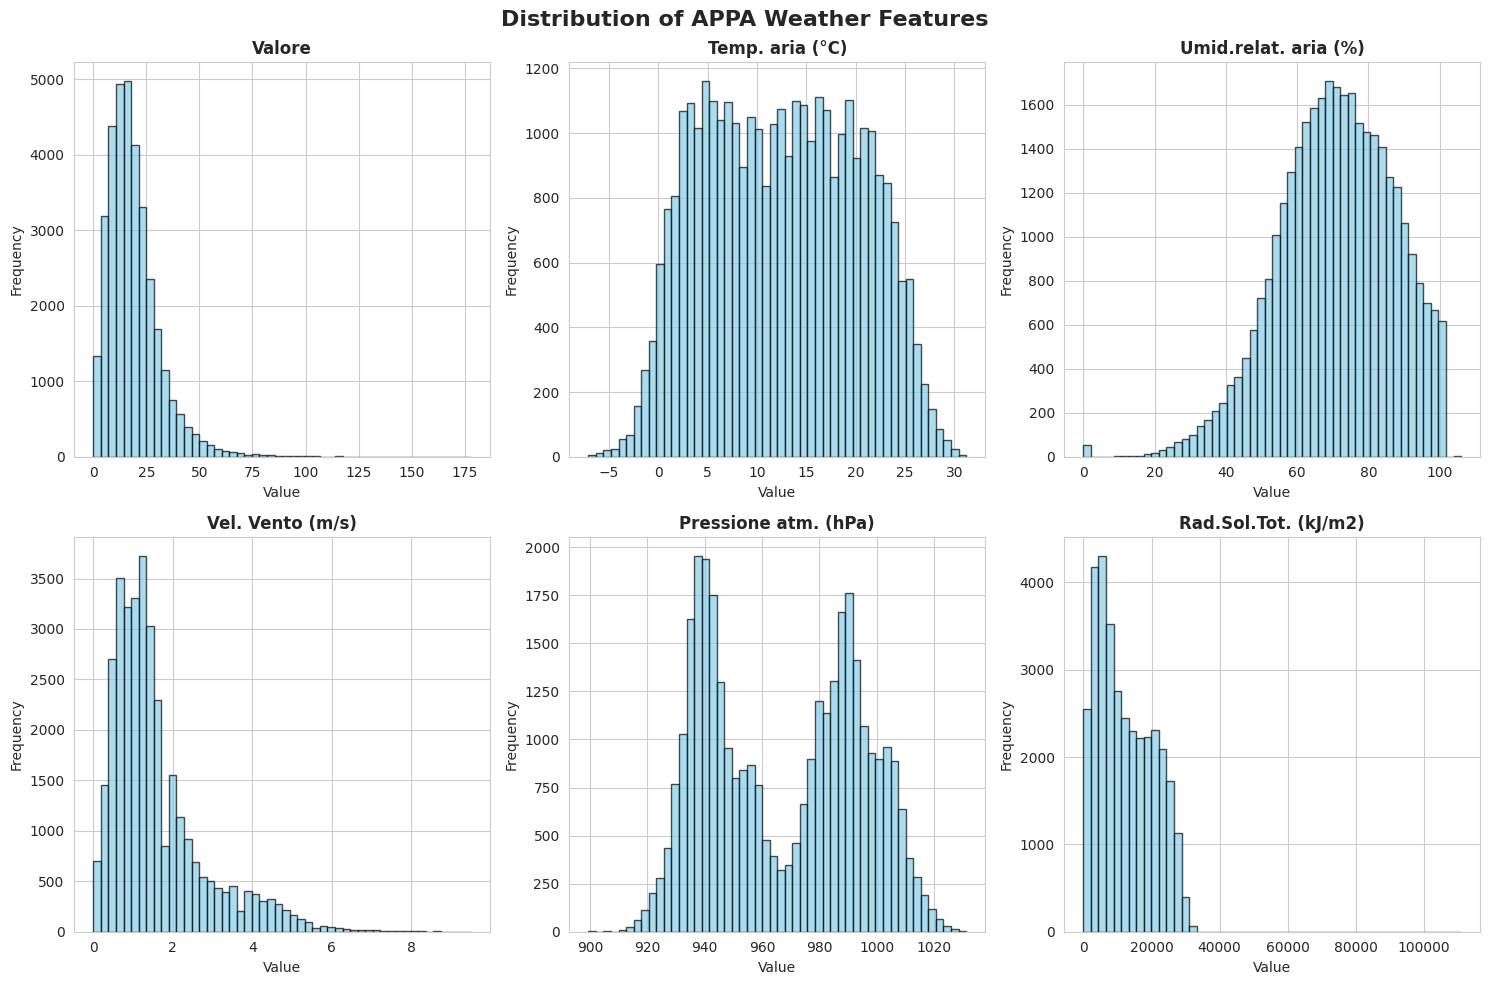

Distribution plots created successfully!


In [11]:
# Create subplots for APPA features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of APPA Weather Features', fontsize=16, fontweight='bold')

features = ['Valore', 'Temp. aria (°C)', 'Umid.relat. aria (%)', 
            'Vel. Vento (m/s)', 'Pressione atm. (hPa)', 'Rad.Sol.Tot. (kJ/m2)']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    data = merged_df[feature].dropna()
    ax.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Distribution plots created successfully!")

## 11. Correlation Analysis - APPA Features

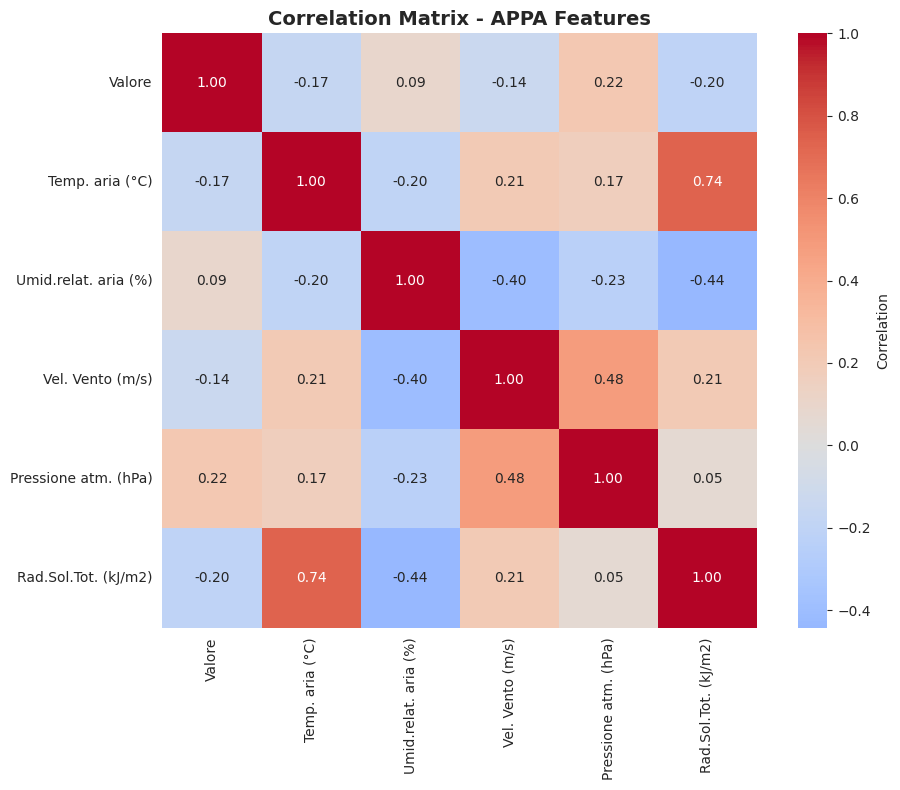


Correlation Matrix:
                      Valore  Temp. aria (°C)  Umid.relat. aria (%)  \
Valore                 1.000           -0.166                 0.088   
Temp. aria (°C)       -0.166            1.000                -0.200   
Umid.relat. aria (%)   0.088           -0.200                 1.000   
Vel. Vento (m/s)      -0.138            0.207                -0.405   
Pressione atm. (hPa)   0.217            0.168                -0.234   
Rad.Sol.Tot. (kJ/m2)  -0.205            0.735                -0.442   

                      Vel. Vento (m/s)  Pressione atm. (hPa)  \
Valore                          -0.138                 0.217   
Temp. aria (°C)                  0.207                 0.168   
Umid.relat. aria (%)            -0.405                -0.234   
Vel. Vento (m/s)                 1.000                 0.482   
Pressione atm. (hPa)             0.482                 1.000   
Rad.Sol.Tot. (kJ/m2)             0.210                 0.054   

                      Rad.Sol.To

In [12]:
# Correlation matrix for APPA features
correlation_data = merged_df[numeric_appa].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - APPA Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation_data.round(3))

## 12. Time Series Analysis

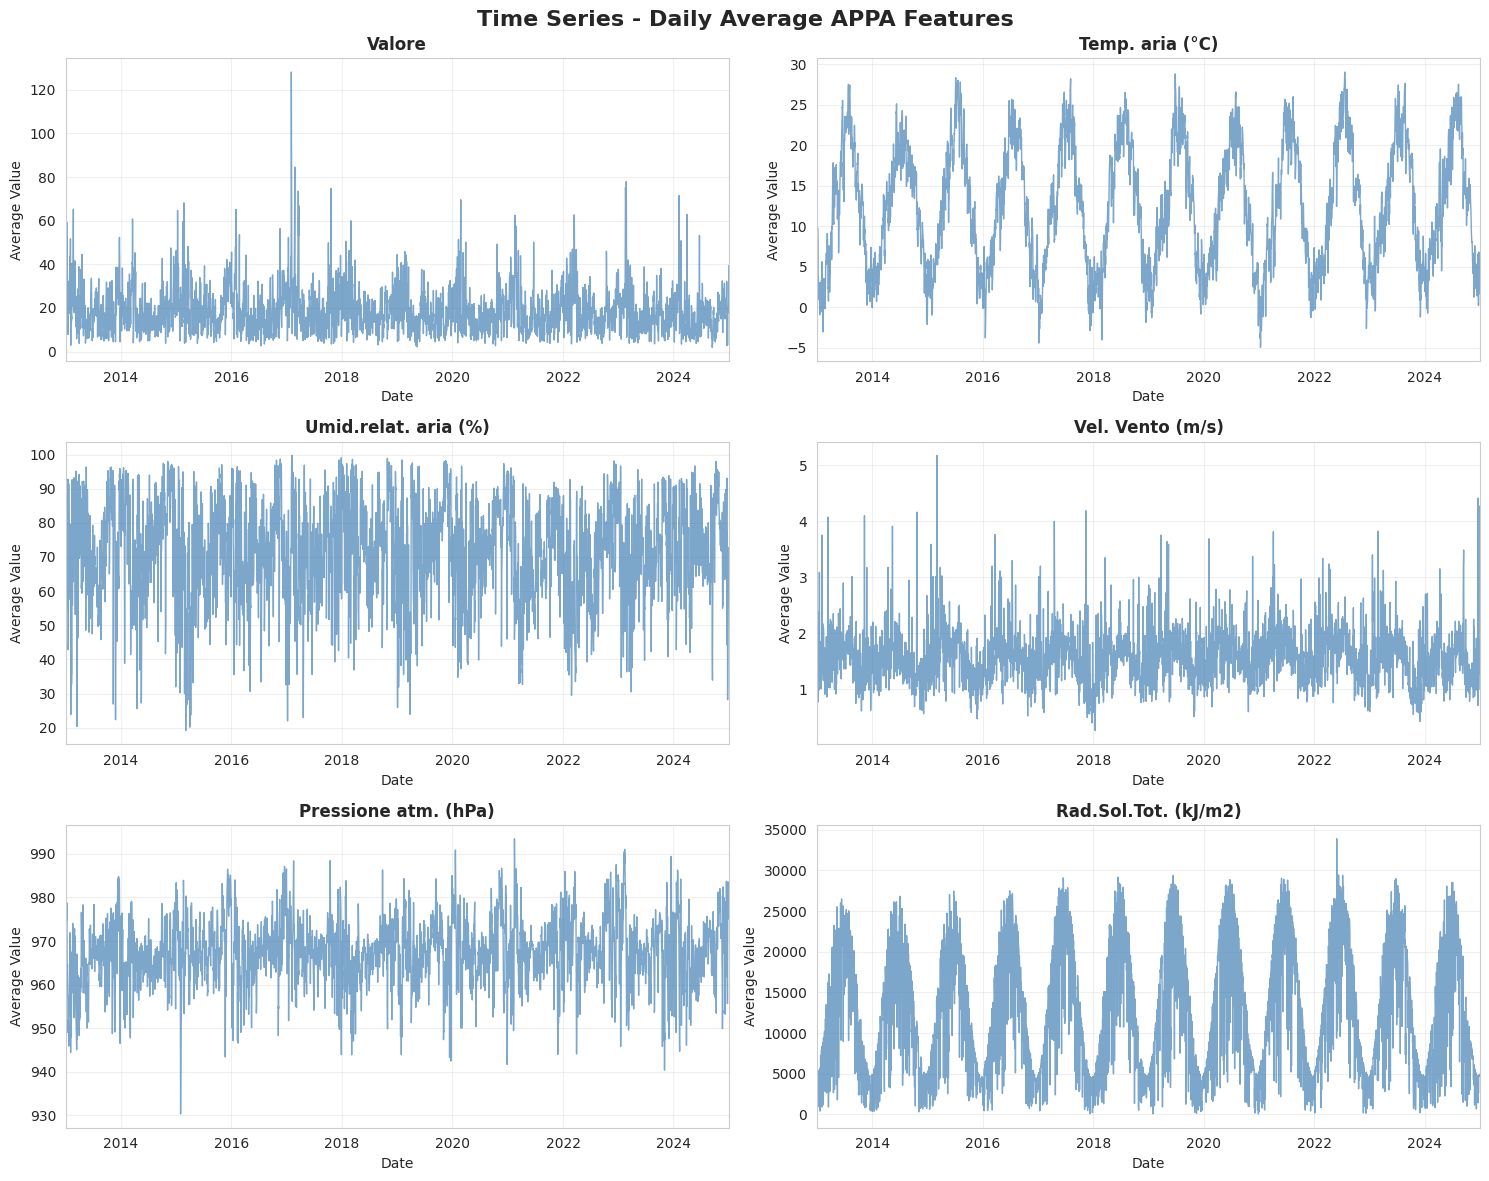

Time series plots created successfully!


In [13]:
# Aggregate by date to see daily patterns
daily_avg = merged_df.groupby('Data')[numeric_appa].mean()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Time Series - Daily Average APPA Features', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_appa):
    ax = axes[idx // 2, idx % 2]
    daily_avg[feature].plot(ax=ax, color='steelblue', linewidth=1, alpha=0.7)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series plots created successfully!")

## 13. Summary Statistics

In [14]:
print("=== DATASET SUMMARY ===")
print(f"\n✓ Total Records: {len(merged_df):,}")
print(f"✓ Total Columns: {merged_df.shape[1]:,}")
print(f"  - APPA Original Columns: {len(appa_cols)}")
print(f"  - EEA Pivoted Columns: {len(eea_cols)}")
print(f"\n✓ Unique APPA Stations: {merged_df['Stazione'].nunique()}")
print(f"✓ Unique EEA Regions: {len(regions)}")
print(f"✓ Date Range: {merged_df['Data'].min().date()} to {merged_df['Data'].max().date()}")
print(f"✓ Total Days Covered: {(merged_df['Data'].max() - merged_df['Data'].min()).days + 1}")
print(f"\n✓ Memory Usage: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDataset ready for analysis and machine learning!")

=== DATASET SUMMARY ===

✓ Total Records: 34,302
✓ Total Columns: 152
  - APPA Original Columns: 20
  - EEA Pivoted Columns: 132

✓ Unique APPA Stations: 8
✓ Unique EEA Regions: 33
✓ Date Range: 2013-01-01 to 2025-01-01
✓ Total Days Covered: 4384

✓ Memory Usage: 97.60 MB

Dataset ready for analysis and machine learning!
